# 03 Classical ML Baselines

Objective: train leakage-safe classical, statistical, tree, boosting, Bayesian/probabilistic, and persistence baselines on the main training split, use validation evidence for model choices and interval calibration, evaluate on validation and locked internal test, then perform locked external validation after model selection, and save model artifacts, predictions, metrics, and article-grade figures.


In [1]:

from pathlib import Path
import json, math, random, time, warnings, textwrap, os
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display
from joblib import dump, load
from sklearn.base import clone
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, HuberRegressor, BayesianRidge, QuantileRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
SEED=20260621
random.seed(SEED); np.random.seed(SEED)
PROJECT_ROOT=Path.cwd()
if not (PROJECT_ROOT/"FOR_AGENTS.md").exists(): PROJECT_ROOT=PROJECT_ROOT.parent
PROCESSED_DIR=PROJECT_ROOT/"data"/"processed"; ARTIFACTS_DIR=PROJECT_ROOT/"artifacts"; FIGURES_DIR=ARTIFACTS_DIR/"figures"; TABLES_DIR=ARTIFACTS_DIR/"tables"; METRICS_DIR=ARTIFACTS_DIR/"metrics"; MODELS_DIR=ARTIFACTS_DIR/"models"; PRED_DIR=ARTIFACTS_DIR/"predictions"; CONFIGS_DIR=ARTIFACTS_DIR/"configs"
MODEL_DIR=MODELS_DIR/"03_best_classical_models"
for p in [FIGURES_DIR,TABLES_DIR,METRICS_DIR,MODEL_DIR,PRED_DIR,CONFIGS_DIR]: p.mkdir(parents=True, exist_ok=True)
mpl.rcParams.update({"font.family":"Times New Roman","font.size":18,"axes.titlesize":20,"axes.labelsize":18,"xtick.labelsize":18,"ytick.labelsize":18,"legend.fontsize":18,"figure.dpi":350,"savefig.dpi":350,"axes.grid":True,"grid.alpha":0.25,"axes.unicode_minus":True})
# Clean only Notebook 03-owned outputs to avoid stale models from earlier interrupted runs.
for stale in MODEL_DIR.glob("*.joblib"):
    stale.unlink()
for stale in [METRICS_DIR/"03_classical_ml_metrics.csv", PRED_DIR/"03_classical_ml_predictions.parquet", TABLES_DIR/"07_classical_ml_leaderboard.csv"]:
    if stale.exists():
        stale.unlink()
CONFIG={"seed":SEED,"external_policy":"Locked external data are evaluated only after validation/internal model selection; no external data are used for training, model selection, or interval calibration.","interval_policy":"Point models receive validation-calibrated residual intervals without using internal test data.","feature_selection_source":"train-only full mutual-information table from Notebook 02 when available"}
(CONFIGS_DIR/"03_classical_ml_config.json").write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")
print(json.dumps(CONFIG, indent=2))

def format_typographic_number(value, decimals=3, use_commas=False):
    try:
        text=(f"{float(value):,.{decimals}f}" if use_commas else f"{float(value):.{decimals}f}")
    except Exception:
        text=str(value)
    return text.replace("-","−")

def axis_uses_dates(axis):
    formatter_name=type(axis.get_major_formatter()).__name__.lower()
    converter_name=type(getattr(axis, "converter", None)).__name__.lower()
    units_text=str(getattr(axis, "units", "")).lower()
    return "date" in formatter_name or "date" in converter_name or "date" in units_text

def apply_typographic_axis_formatting(fig):
    comma_formatter=mpl.ticker.FuncFormatter(lambda x,pos: f"{x:,.0f}".replace("-","−"))
    for ax in fig.axes:
        for axis in [getattr(ax,"xaxis",None), getattr(ax,"yaxis",None)]:
            if axis is None or axis_uses_dates(axis):
                continue
            ticks=np.asarray(axis.get_majorticklocs(), dtype=float)
            finite=ticks[np.isfinite(ticks)]
            if finite.size and np.nanmax(np.abs(finite)) >= 10000:
                axis.set_major_formatter(comma_formatter)
def save_figure(fig, filename, bottom=0.20, left=None, right=0.98, top=0.90):
    if left is not None:
        fig.subplots_adjust(left=left, right=right, top=top, bottom=bottom)
    else:
        fig.subplots_adjust(right=right, top=top, bottom=bottom)
    apply_typographic_axis_formatting(fig)
    path=FIGURES_DIR/filename; fig.savefig(path, dpi=350, bbox_inches="tight", pad_inches=0.25); plt.show(); print(f"Saved figure: {path.relative_to(PROJECT_ROOT)}")
def legend_below(ax, ncol=3):
    handles, labels=ax.get_legend_handles_labels()
    if handles: ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5,-0.18), ncol=ncol, frameon=False)
def annotate_bars(ax, fmt="{:.3f}"):
    max_width=max([p.get_width() for p in ax.patches] + [0])
    if max_width > 0:
        ax.set_xlim(0, max_width*1.20)
    xlim=ax.get_xlim()[1]
    for patch in ax.patches:
        width=patch.get_width()
        xpos=min(width + xlim*0.015, xlim*0.965)
        ax.text(xpos, patch.get_y()+patch.get_height()/2, fmt.format(width).replace("-","−"), va="center", ha="left", fontsize=18)



{
  "seed": 20260621,
  "external_policy": "Locked external data are evaluated only after validation/internal model selection; no external data are used for training, model selection, or interval calibration.",
  "interval_policy": "Point models receive validation-calibrated residual intervals without using internal test data.",
  "feature_selection_source": "train-only full mutual-information table from Notebook 02 when available"
}


In [2]:
def model_params_json(model):
    if hasattr(model,"get_params"):
        try:
            return json.dumps(model.get_params(deep=False), default=str)
        except TypeError:
            return json.dumps({k:str(v) for k,v in model.get_params(deep=False).items()})
    return "{}"


In [3]:
# Load processed train, validation, internal test, and locked external matrices.
X_train=pd.read_parquet(PROCESSED_DIR/"X_train.parquet"); X_val=pd.read_parquet(PROCESSED_DIR/"X_val.parquet"); X_test=pd.read_parquet(PROCESSED_DIR/"X_test.parquet"); X_external=pd.read_parquet(PROCESSED_DIR/"X_external.parquet")
y_train=pd.read_parquet(PROCESSED_DIR/"y_train.parquet"); y_val=pd.read_parquet(PROCESSED_DIR/"y_val.parquet"); y_test=pd.read_parquet(PROCESSED_DIR/"y_test.parquet"); y_external=pd.read_parquet(PROCESSED_DIR/"y_external.parquet")
meta_train=pd.read_parquet(PROCESSED_DIR/"meta_train.parquet"); meta_val=pd.read_parquet(PROCESSED_DIR/"meta_val.parquet"); meta_test=pd.read_parquet(PROCESSED_DIR/"meta_test.parquet"); meta_external=pd.read_parquet(PROCESSED_DIR/"meta_external.parquet")
main_frame=pd.read_parquet(PROCESSED_DIR/"modeling_frame_main.parquet")
external_frame=pd.read_parquet(PROCESSED_DIR/"modeling_frame_external.parquet")
feature_cols=X_train.columns.tolist(); target_cols=y_train.columns.tolist()
print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape, "X_external:", X_external.shape, "targets:", y_train.shape)
display(pd.DataFrame({"feature_count":[len(feature_cols)],"target_count":[len(target_cols)],"train_rows":[len(X_train)],"validation_rows":[len(X_val)],"test_rows":[len(X_test)],"external_locked_rows":[len(X_external)]}))

def parse_target_col(col):
    base,h=col.rsplit("_h",1)
    return base.replace("_power",""), int(h)
TRAIN_SCALE={}
for col in target_cols:
    denom_range=max(y_train[col].max()-y_train[col].min(), 1e-6)
    denom_mase=max(np.mean(np.abs(np.diff(y_train[col].values))), 1e-6)
    TRAIN_SCALE[col]={"range":float(denom_range),"mase":float(denom_mase)}


X_train: (6109, 422) X_val: (1309, 422) X_test: (1310, 422) X_external: (17520, 422) targets: (6109, 15)


,feature_count,target_count,train_rows,validation_rows,test_rows,external_locked_rows
0,422,15,6109,1309,1310,17520


In [4]:

# Metrics and prediction helpers.
def make_long_predictions(model_name, split_name, meta, y_true_df, y_pred_arr, lower_arr=None, upper_arr=None, uncertainty_arr=None):
    rows=[]; y_pred_arr=np.asarray(y_pred_arr)
    if lower_arr is None: lower_arr=np.full_like(y_pred_arr, np.nan, dtype=float)
    if upper_arr is None: upper_arr=np.full_like(y_pred_arr, np.nan, dtype=float)
    if uncertainty_arr is None: uncertainty_arr=(upper_arr-lower_arr)/2
    timestamps=meta["timestamp"].astype(str).values
    dataset=meta["dataset"].astype(str).values if "dataset" in meta.columns else np.repeat("main_mendeley", len(meta))
    for j,col in enumerate(target_cols):
        target,h=parse_target_col(col)
        rows.append(pd.DataFrame({"split":split_name,"dataset":dataset,"timestamp":timestamps,"target":target,"horizon":h,"y_true":y_true_df[col].values,"y_pred":y_pred_arr[:,j],"lower":lower_arr[:,j],"upper":upper_arr[:,j],"uncertainty":uncertainty_arr[:,j],"model_name":model_name}))
    return pd.concat(rows, ignore_index=True)

def point_metric_rows(pred_df, train_scale=TRAIN_SCALE):
    rows=[]
    for (model,split,target,h),g in pred_df.groupby(["model_name","split","target","horizon"]):
        col=f"{target}_power_h{h}"
        y=g.y_true.values; p=g.y_pred.values
        mae=float(np.mean(np.abs(y-p))); rmse=float(np.sqrt(np.mean((y-p)**2)))
        denom=train_scale.get(col,{"range":max(np.max(y)-np.min(y),1e-6),"mase":1.0})
        smape=float(np.mean(2*np.abs(p-y)/(np.abs(y)+np.abs(p)+1e-6)))
        mape=float(np.mean(np.abs((y-p)/np.maximum(np.abs(y),0.05))))
        try: r2=float(r2_score(y,p))
        except Exception: r2=np.nan
        picp=float(np.mean((y>=g.lower.values)&(y<=g.upper.values))) if g.lower.notna().any() else np.nan
        width=float(np.nanmean(g.upper.values-g.lower.values)) if g.lower.notna().any() else np.nan
        alpha=0.10
        below=np.maximum(g.lower.values-y,0); above=np.maximum(y-g.upper.values,0)
        winkler=float(np.nanmean(width + (2/alpha)*below + (2/alpha)*above)) if np.isfinite(width) else np.nan
        pinball=float(np.nanmean(np.maximum(0.5*(y-p), (0.5-1)*(y-p))))
        rows.append({"model_name":model,"split":split,"target":target,"horizon":h,"MAE":mae,"RMSE":rmse,"nRMSE":rmse/denom["range"],"MASE":mae/denom["mase"],"sMAPE":smape,"MAPE_safe":mape,"R2":r2,"PinballLoss_median":pinball,"PICP90":picp,"MeanIntervalWidth":width,"Winkler90":winkler})
    return pd.DataFrame(rows)

def validation_residual_intervals(val_true, val_pred, pred, alpha=0.10):
    q=np.quantile(np.abs(val_true-val_pred), 1-alpha, axis=0)
    return pred-q, pred+q, np.tile(q, (len(pred),1))


In [5]:
# Naive, seasonal persistence, and rolling mean baselines.
def frame_for_split(split):
    if split=="external_locked":
        return external_frame.reset_index(drop=True)
    return main_frame[main_frame.split.eq(split)].reset_index(drop=True)
def naive_prediction(split, kind):
    frame=frame_for_split(split)
    pred=np.zeros((len(frame), len(target_cols)))
    for j,col in enumerate(target_cols):
        target,h=parse_target_col(col); base=f"{target}_power"
        if kind=="Persistence": source=base
        elif kind=="SeasonalPersistence": source=f"{base}_lag_24"
        else: source=f"{base}_roll_mean_24"
        if source in frame.columns:
            pred[:,j]=frame[source].fillna(frame[base]).fillna(y_train[col].median()).values
        else:
            pred[:,j]=frame[base].fillna(y_train[col].median()).values
    return pred
prediction_frames=[]; model_records=[]
for name in ["Persistence","SeasonalPersistence","RollingMean24"]:
    t0=time.time(); val_pred=naive_prediction("validation", name); test_pred=naive_prediction("internal_test", name); external_pred=naive_prediction("external_locked", name); train_time=0.0
    val_lower,val_upper,val_unc=validation_residual_intervals(y_val.values,val_pred,val_pred)
    test_lower,test_upper,test_unc=validation_residual_intervals(y_val.values,val_pred,test_pred)
    ext_lower,ext_upper,ext_unc=validation_residual_intervals(y_val.values,val_pred,external_pred)
    prediction_frames.append(make_long_predictions(name,"validation",meta_val,y_val,val_pred,val_lower,val_upper,val_unc))
    prediction_frames.append(make_long_predictions(name,"internal_test",meta_test,y_test,test_pred,test_lower,test_upper,test_unc))
    prediction_frames.append(make_long_predictions(name,"external_locked",meta_external,y_external,external_pred,ext_lower,ext_upper,ext_unc))
    model_records.append({"model_name":name,"family":"naive","train_time_sec":train_time,"inference_time_sec":time.time()-t0,"model_path":"not_applicable","hyperparameters":json.dumps({"kind":name})})
print("Naive baselines completed:", [r["model_name"] for r in model_records])


Naive baselines completed: ['Persistence', 'SeasonalPersistence', 'RollingMean24']


In [6]:
# Validation-based classical, probabilistic, tree, and boosting model training.
def fit_model_record(model_name, family, estimator, use_feature_subset=None, train_row_indices=None):
    cols=use_feature_subset or feature_cols
    Xtr_all=X_train[cols]
    ytr_all=y_train.values
    if train_row_indices is not None:
        idx=np.asarray(train_row_indices, dtype=int)
        Xtr=Xtr_all.iloc[idx]
        ytr=y_train.iloc[idx].values
    else:
        Xtr=Xtr_all
        ytr=ytr_all
    Xv=X_val[cols]; Xt=X_test[cols]; Xe=X_external[cols]
    t0=time.time(); model=estimator
    model.fit(Xtr, ytr)
    train_time=time.time()-t0
    t1=time.time(); val_pred=np.asarray(model.predict(Xv)); test_pred=np.asarray(model.predict(Xt)); external_pred=np.asarray(model.predict(Xe)); inference_time=time.time()-t1
    val_lower,val_upper,val_unc=validation_residual_intervals(y_val.values,val_pred,val_pred)
    test_lower,test_upper,test_unc=validation_residual_intervals(y_val.values,val_pred,test_pred)
    ext_lower,ext_upper,ext_unc=validation_residual_intervals(y_val.values,val_pred,external_pred)
    prediction_frames.append(make_long_predictions(model_name,"validation",meta_val,y_val,val_pred,val_lower,val_upper,val_unc))
    prediction_frames.append(make_long_predictions(model_name,"internal_test",meta_test,y_test,test_pred,test_lower,test_upper,test_unc))
    prediction_frames.append(make_long_predictions(model_name,"external_locked",meta_external,y_external,external_pred,ext_lower,ext_upper,ext_unc))
    path=MODEL_DIR/f"{model_name}.joblib"
    dump({"model":model,"feature_columns":cols,"target_columns":target_cols,"family":family,"train_row_count":len(Xtr)}, path)
    model_records.append({"model_name":model_name,"family":family,"train_time_sec":train_time,"inference_time_sec":inference_time,"model_path":str(path.relative_to(PROJECT_ROOT)),"hyperparameters":model_params_json(model),"train_row_count":len(Xtr),"feature_count":len(cols)})
    print(f"{model_name}: val MAE={mean_absolute_error(y_val.values,val_pred):.4f}, test MAE={mean_absolute_error(y_test.values,test_pred):.4f}, external MAE={mean_absolute_error(y_external.values,external_pred):.4f}, rows={len(Xtr)}, features={len(cols)}, train_time={train_time:.1f}s")
    return model

# Train-only feature subset for expensive probabilistic models.
mi_rank_path=TABLES_DIR/"06c_full_mutual_information_feature_target_table.csv"
if mi_rank_path.exists():
    feature_rank=pd.read_csv(mi_rank_path)
    if "feature" not in feature_rank.columns:
        feature_rank=feature_rank.rename(columns={feature_rank.columns[0]:"feature"})
    feature_rank=feature_rank.sort_values("mean_mi", ascending=False)
else:
    corr_rank=X_train.corrwith(y_train["total_power_h1"]).abs().sort_values(ascending=False)
    feature_rank=pd.DataFrame({"feature":corr_rank.index, "mean_mi":corr_rank.values})
top80=[f for f in feature_rank["feature"].tolist() if f in feature_cols][:80]
top50=top80[:50]
top30=top80[:30]
models_to_train=[]
models_to_train.append(("LinearRegression","linear_statistical",LinearRegression(n_jobs=-1),None))


In [7]:
# Ridge validation search.
best_ridge=None; best_score=np.inf
for alpha in [0.1,1.0,10.0,50.0]:
    model=Ridge(alpha=alpha, random_state=SEED); model.fit(X_train,y_train); pred=model.predict(X_val); score=mean_absolute_error(y_val,pred)
    if score<best_score: best_score=score; best_ridge=model
models_to_train.append(("Ridge_validation_selected","linear_statistical",best_ridge,None))
models_to_train.append(("ElasticNet","linear_statistical",MultiOutputRegressor(ElasticNet(alpha=0.0005,l1_ratio=0.2,max_iter=5000,random_state=SEED)),None))
models_to_train.append(("HuberRegression","linear_statistical",MultiOutputRegressor(HuberRegressor(epsilon=1.35,alpha=0.0001,max_iter=300)),top80))
models_to_train.append(("BayesianRidge","bayesian_probabilistic",MultiOutputRegressor(BayesianRidge()),top80))
models_to_train.append(("RandomForest","tree_ensemble",RandomForestRegressor(n_estimators=90,max_depth=14,min_samples_leaf=2,n_jobs=-1,random_state=SEED),None))
models_to_train.append(("ExtraTrees","tree_ensemble",ExtraTreesRegressor(n_estimators=140,max_depth=None,min_samples_leaf=1,n_jobs=-1,random_state=SEED),None))
models_to_train.append(("HistGradientBoosting","boosting",MultiOutputRegressor(HistGradientBoostingRegressor(max_iter=160,learning_rate=0.06,max_leaf_nodes=31,l2_regularization=0.02,random_state=SEED)),None))
try:
    from xgboost import XGBRegressor
    models_to_train.append(("XGBoost","boosting",MultiOutputRegressor(XGBRegressor(n_estimators=180,max_depth=4,learning_rate=0.045,subsample=0.9,colsample_bytree=0.85,objective="reg:squarederror",random_state=SEED,n_jobs=4)),None))
except Exception as exc:
    print("XGBoost unavailable:", exc)
try:
    from lightgbm import LGBMRegressor
    models_to_train.append(("LightGBM","boosting",MultiOutputRegressor(LGBMRegressor(n_estimators=220,learning_rate=0.045,num_leaves=31,subsample=0.9,colsample_bytree=0.85,random_state=SEED,n_jobs=4,verbose=-1)),None))
except Exception as exc:
    print("LightGBM unavailable:", exc)
try:
    from catboost import CatBoostRegressor
    models_to_train.append(("CatBoost","boosting",CatBoostRegressor(iterations=220,depth=5,learning_rate=0.045,loss_function="MultiRMSE",random_seed=SEED,verbose=False,allow_writing_files=False),None))
except Exception as exc:
    print("CatBoost unavailable:", exc)
# Reduced probabilistic/quantile models are fitted on train-selected feature subsets and train-row subsets for tractability.
try:
    gp_idx=np.linspace(0,len(X_train)-1,min(600,len(X_train)),dtype=int)
    gp=MultiOutputRegressor(GaussianProcessRegressor(kernel=ConstantKernel(1.0)*RBF(length_scale=1.0)+WhiteKernel(noise_level=0.01), optimizer=None, normalize_y=True, random_state=SEED))
    fit_model_record("GaussianProcessReduced","bayesian_probabilistic",gp,top50,train_row_indices=gp_idx)
except Exception as exc:
    print("GaussianProcessReduced skipped:", exc)
try:
    qmed=MultiOutputRegressor(GradientBoostingRegressor(loss="quantile", alpha=0.5, n_estimators=80, max_depth=3, learning_rate=0.06, random_state=SEED))
    fit_model_record("QuantileGradientBoostingMedian","probabilistic_quantile",qmed,top80)
except Exception as exc:
    print("QuantileGradientBoostingMedian skipped:", exc)


GaussianProcessReduced: val MAE=0.1390, test MAE=0.1150, external MAE=0.1041, rows=600, features=50, train_time=0.3s


QuantileGradientBoostingMedian: val MAE=0.1064, test MAE=0.0865, external MAE=0.0747, rows=6109, features=80, train_time=86.5s


In [8]:
try:
    qr_idx=np.linspace(0,len(X_train)-1,min(1600,len(X_train)),dtype=int)
    qr=MultiOutputRegressor(QuantileRegressor(quantile=0.5, alpha=0.001, solver="highs"))
    fit_model_record("LinearQuantileRegressionMedian","probabilistic_quantile",qr,top30,train_row_indices=qr_idx)
except Exception as exc:
    print("LinearQuantileRegressionMedian skipped:", exc)
for model_name,family,estimator,cols in models_to_train:
    try:
        fit_model_record(model_name,family,estimator,cols)
    except Exception as exc:
        print(f"{model_name} skipped due to error: {exc}")
records_df=pd.DataFrame(model_records)
display(records_df)


LinearQuantileRegressionMedian: val MAE=0.1338, test MAE=0.0983, external MAE=0.0869, rows=1600, features=30, train_time=2.7s


LinearRegression: val MAE=0.1313, test MAE=0.1120, external MAE=117.3823, rows=6109, features=422, train_time=0.2s
Ridge_validation_selected: val MAE=0.1131, test MAE=0.0969, external MAE=0.0942, rows=6109, features=422, train_time=0.0s


ElasticNet: val MAE=0.1166, test MAE=0.0991, external MAE=0.1053, rows=6109, features=422, train_time=44.8s


HuberRegression: val MAE=0.1242, test MAE=0.1005, external MAE=0.1681, rows=6109, features=80, train_time=6.1s


BayesianRidge: val MAE=0.1232, test MAE=0.1011, external MAE=0.1752, rows=6109, features=80, train_time=0.5s


...

HistGradientBoosting: val MAE=0.0993, test MAE=0.0827, external MAE=0.0808, rows=6109, features=422, train_time=87.8s


XGBoost: val MAE=0.0990, test MAE=0.0839, external MAE=0.0771, rows=6109, features=422, train_time=22.5s


LightGBM: val MAE=0.0993, test MAE=0.0822, external MAE=0.0803, rows=6109, features=422, train_time=29.2s


CatBoost: val MAE=0.1079, test MAE=0.0943, external MAE=0.0729, rows=6109, features=422, train_time=13.2s


,model_name,family,train_time_sec,inference_time_sec,model_path,hyperparameters,train_row_count,feature_count
0,Persistence,naive,0.000000,0.043188,not_applicable,"{""kind"": ""Persistence""}",NaN,NaN
1,SeasonalPersistence,naive,0.000000,0.041953,not_applicable,"{""kind"": ""SeasonalPersistence""}",NaN,NaN
2,RollingMean24,naive,0.000000,0.039576,not_applicable,"{""kind"": ""RollingMean24""}",NaN,NaN
3,GaussianProcessReduced,bayesian_probabilistic,0.327458,3.947620,artifacts/models/03_best_classical_models/Gaus...,"{""estimator"": ""GaussianProcessRegressor(kernel...",600.0,50.0
4,QuantileGradientBoostingMedian,probabilistic_quantile,86.530287,0.197934,artifacts/models/03_best_classical_models/Quan...,"{""estimator"": ""GradientBoostingRegressor(alpha...",6109.0,80.0
5,LinearQuantileRegressionMedian,probabilistic_quantile,2.667391,0.023178,artifacts/models/03_best_classical_models/Line...,"{""estimator"": ""QuantileRegressor(alpha=0.001)""...",1600.0,30.0
6,LinearRegression,linear_statistical,0.194976,0.014004,artifacts/models/03_best_classical_models/Line...,"{""copy_X"": true, ""fit_intercept"": true, ""n_job...",6109.0,422.0
7,Ridge_validation_selected,linear_statistical,0.025895,0.009935,artifacts/models/03_best_classical_models/Ridg...,"{""alpha"": 50.0, ""copy_X"": true, ""fit_intercept...",6109.0,422.0
8,ElasticNet,linear_statistical,44.766284,0.114032,artifacts/models/03_best_classical_models/Elas...,"{""estimator"": ""ElasticNet(alpha=0.0005, l1_rat...",6109.0,422.0
9,HuberRegression,linear_statistical,6.133921,0.032858,artifacts/models/03_best_classical_models/Hube...,"{""estimator"": ""HuberRegressor(max_iter=300)"", ...",6109.0,80.0


,model_name,family,MAE,RMSE,nRMSE,MASE,R2,PICP90,MeanIntervalWidth,train_time_sec,inference_time_sec
7,LightGBM,boosting,0.082242,0.120182,0.118066,1.700445,0.577149,0.930789,0.471909,29.242403,1.335148
5,HistGradientBoosting,boosting,0.082664,0.120826,0.118710,1.710326,0.571882,0.928804,0.470208,87.764618,1.471317
16,XGBoost,boosting,0.083895,0.120211,0.118150,1.735351,0.575796,0.929873,0.464907,22.482149,0.635503
11,QuantileGradientBoostingMedian,probabilistic_quantile,0.086461,0.128846,0.126499,1.776080,0.531001,0.930534,0.522547,86.530287,0.197934
12,RandomForest,tree_ensemble,0.090517,0.128599,0.126321,1.859888,0.547880,0.932570,0.499995,10.082752,0.078859
3,ExtraTrees,tree_ensemble,0.091317,0.129917,0.127630,1.878071,0.535434,0.920865,0.487374,7.425010,0.127340
1,CatBoost,boosting,0.094288,0.125729,0.123471,1.908050,0.562850,0.932163,0.482492,13.199353,0.038356
13,Ridge_validation_selected,linear_statistical,0.096947,0.131742,0.129345,1.959038,0.507557,0.928753,0.507079,0.025895,0.009935
8,LinearQuantileRegressionMedian,probabilistic_quantile,0.098285,0.143562,0.140993,2.001474,0.435731,0.949313,0.651340,2.667391,0.023178
2,ElasticNet,linear_statistical,0.099076,0.134402,0.131955,2.009889,0.466099,0.929262,0.515001,44.766284,0.114032


,horizon,model_name,family,MAE,RMSE,nRMSE,MASE,R2,PICP90,MeanIntervalWidth
7,1,LightGBM,boosting,0.022425,0.038927,0.038218,0.455653,0.961883,0.936896,0.150589
5,1,HistGradientBoosting,boosting,0.022827,0.039706,0.038975,0.462868,0.960296,0.929771,0.146656
16,1,XGBoost,boosting,0.023533,0.040067,0.039338,0.475608,0.959343,0.935369,0.152592
11,1,QuantileGradientBoostingMedian,probabilistic_quantile,0.028254,0.047857,0.047116,0.582484,0.940153,0.934351,0.194666
2,1,ElasticNet,linear_statistical,0.031236,0.044890,0.044041,0.616276,0.948873,0.939186,0.175412
22,3,HistGradientBoosting,boosting,0.062070,0.096200,0.094535,1.270137,0.766220,0.922137,0.367805
24,3,LightGBM,boosting,0.062298,0.096494,0.094841,1.277710,0.764159,0.925445,0.376739
33,3,XGBoost,boosting,0.063896,0.099257,0.097500,1.303221,0.751546,0.922646,0.373779
28,3,QuantileGradientBoostingMedian,probabilistic_quantile,0.070480,0.109159,0.107146,1.427790,0.701964,0.937659,0.453444
29,3,RandomForest,tree_ensemble,0.070778,0.106951,0.105017,1.440805,0.713502,0.931298,0.417934


,horizon,model_name,family,MAE,RMSE,nRMSE,MASE,R2,PICP90,MeanIntervalWidth
2,1,ElasticNet,linear_statistical,0.031112,0.040506,0.039730,0.620105,0.908503,0.962671,0.175412
10,1,Persistence,naive,0.032716,0.047101,0.046194,0.644517,0.889909,0.995167,0.315472
13,1,Ridge_validation_selected,linear_statistical,0.045297,0.057723,0.056584,0.907873,0.802301,0.927435,0.215192
5,1,HistGradientBoosting,boosting,0.055409,0.080193,0.078337,1.117305,0.600689,0.751027,0.146656
11,1,QuantileGradientBoostingMedian,probabilistic_quantile,0.056813,0.078295,0.076819,1.185382,0.558849,0.809399,0.194666
18,3,CatBoost,boosting,0.068057,0.088654,0.087080,1.381882,0.533650,0.971043,0.407844
33,3,XGBoost,boosting,0.068452,0.092297,0.090508,1.386207,0.497241,0.951027,0.373779
22,3,HistGradientBoosting,boosting,0.070439,0.095356,0.093542,1.429147,0.462627,0.938756,0.367805
28,3,QuantileGradientBoostingMedian,probabilistic_quantile,0.070778,0.095027,0.093303,1.455311,0.433811,0.973231,0.453444
24,3,LightGBM,boosting,0.071715,0.095568,0.093775,1.450797,0.461597,0.944768,0.376739


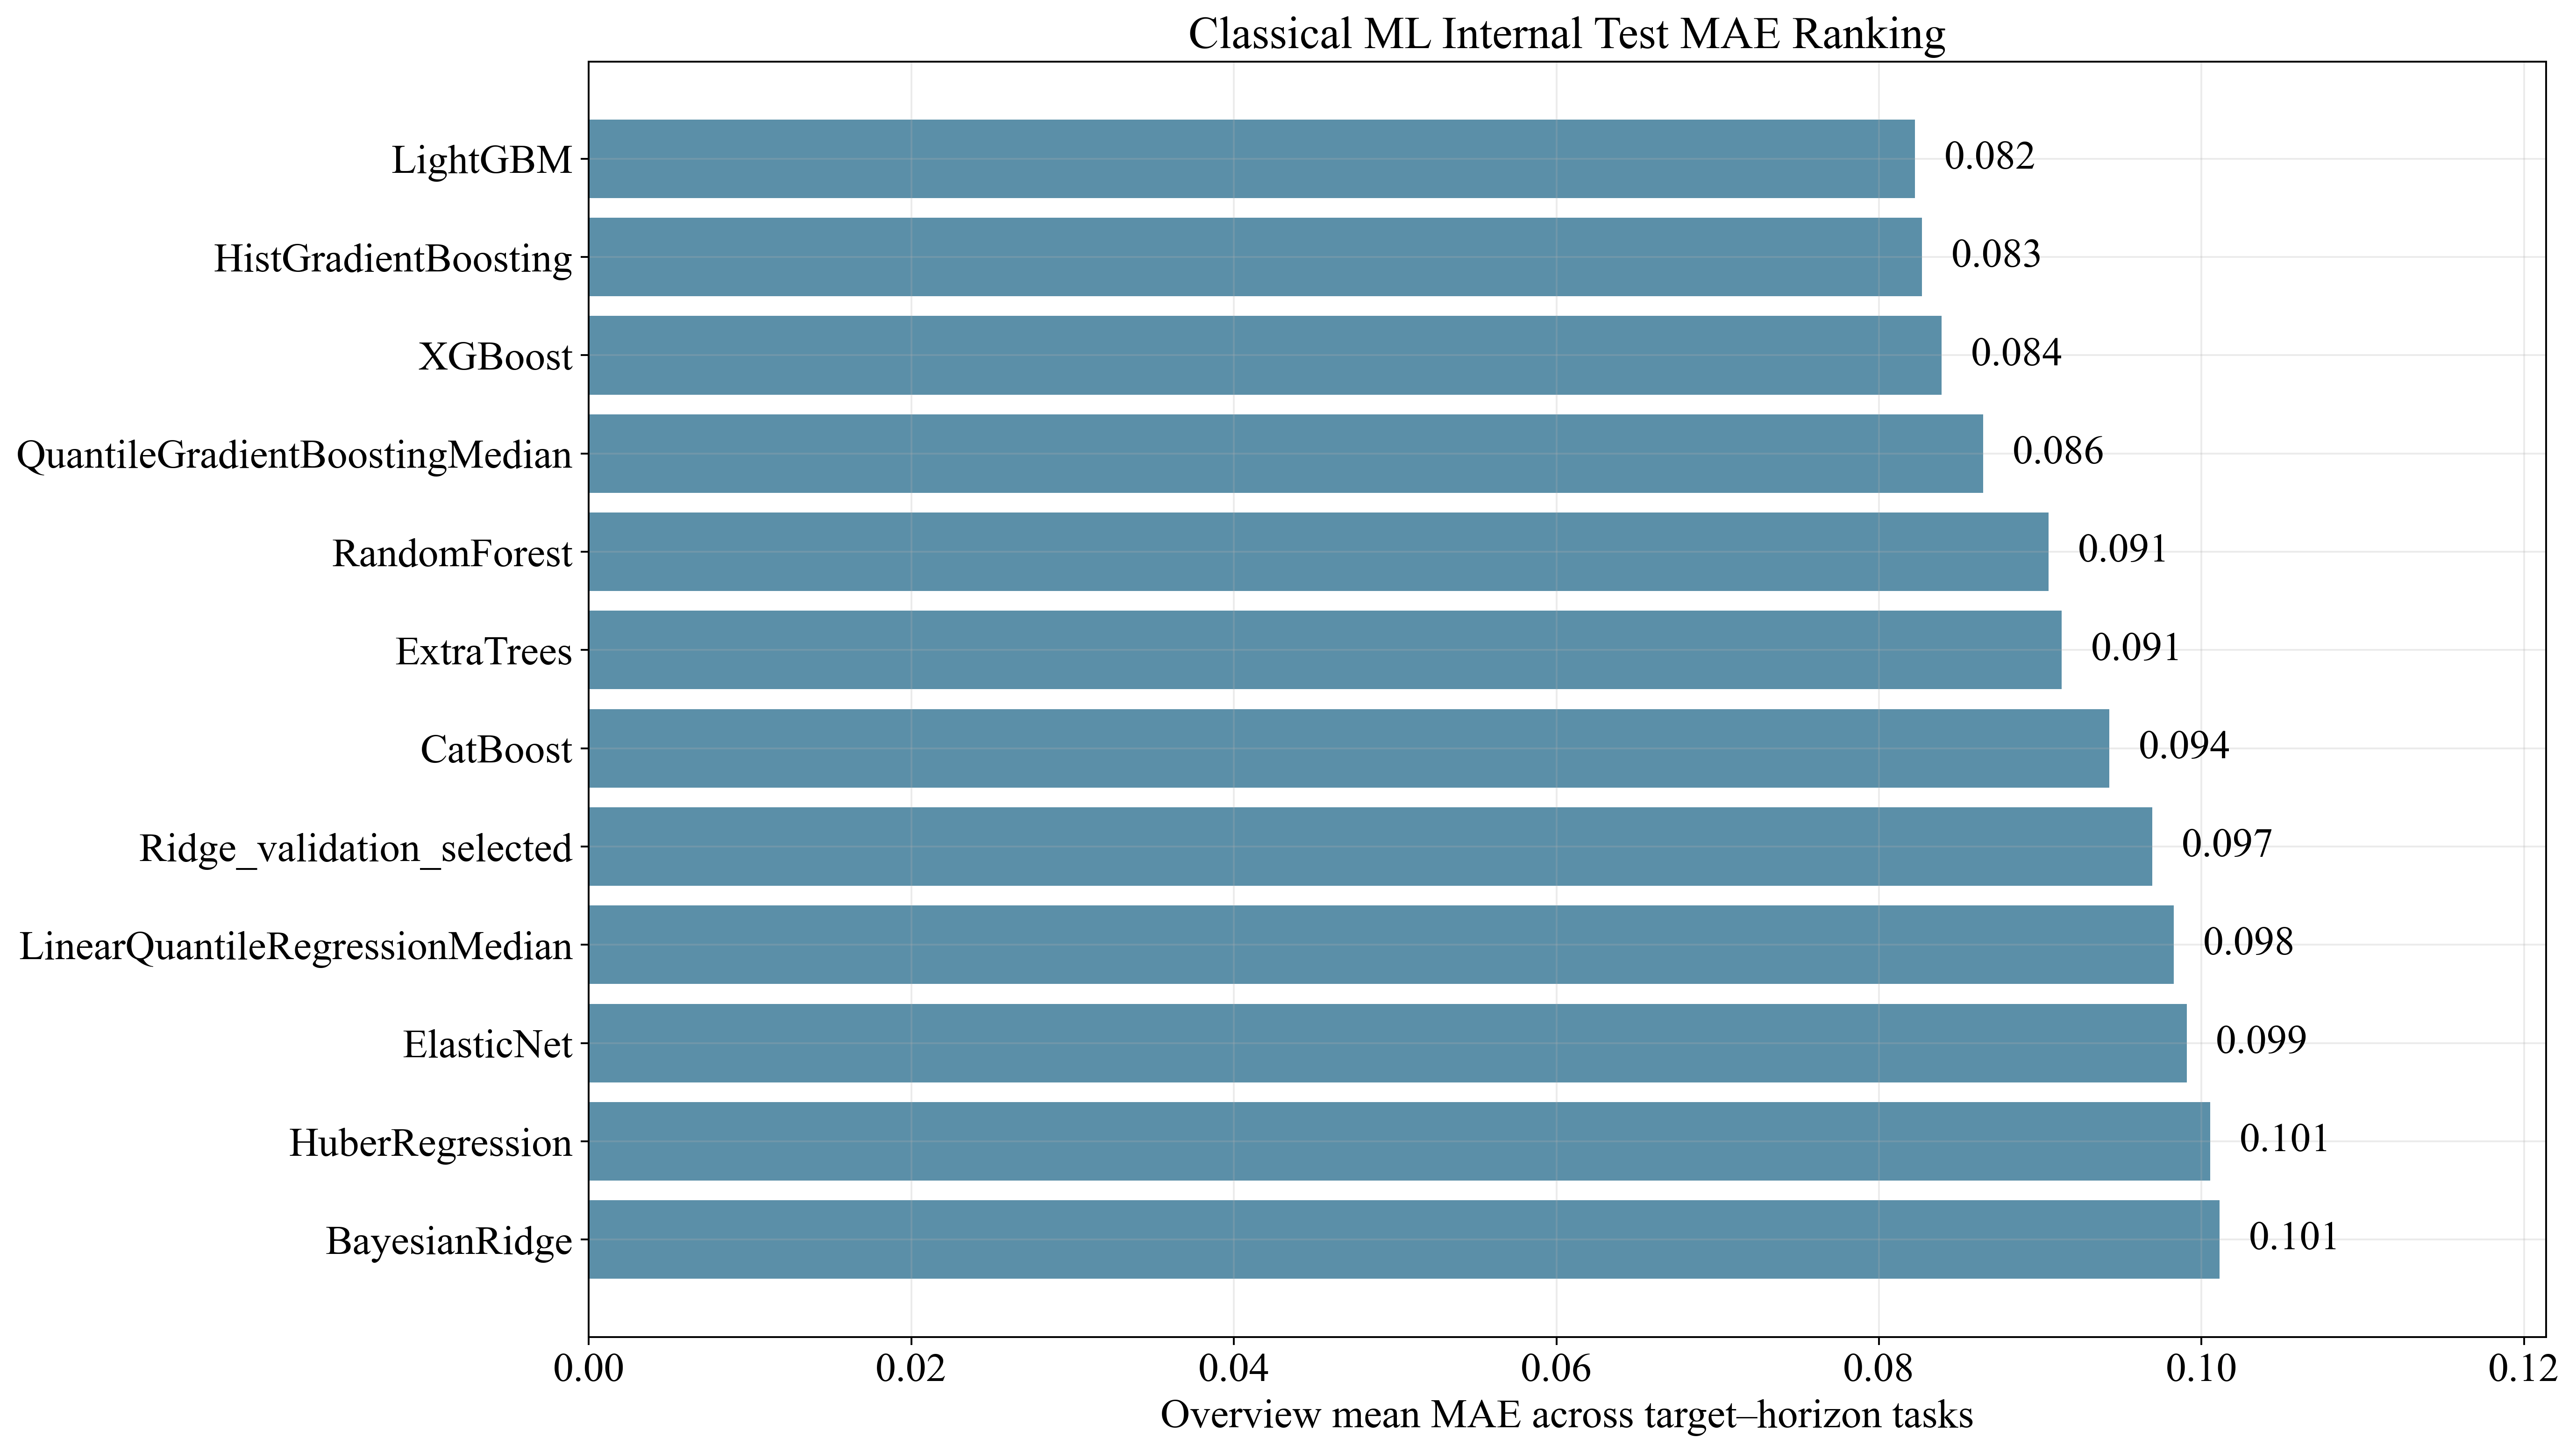

Saved figure: artifacts/figures/20_classical_ml_metric_comparison.png


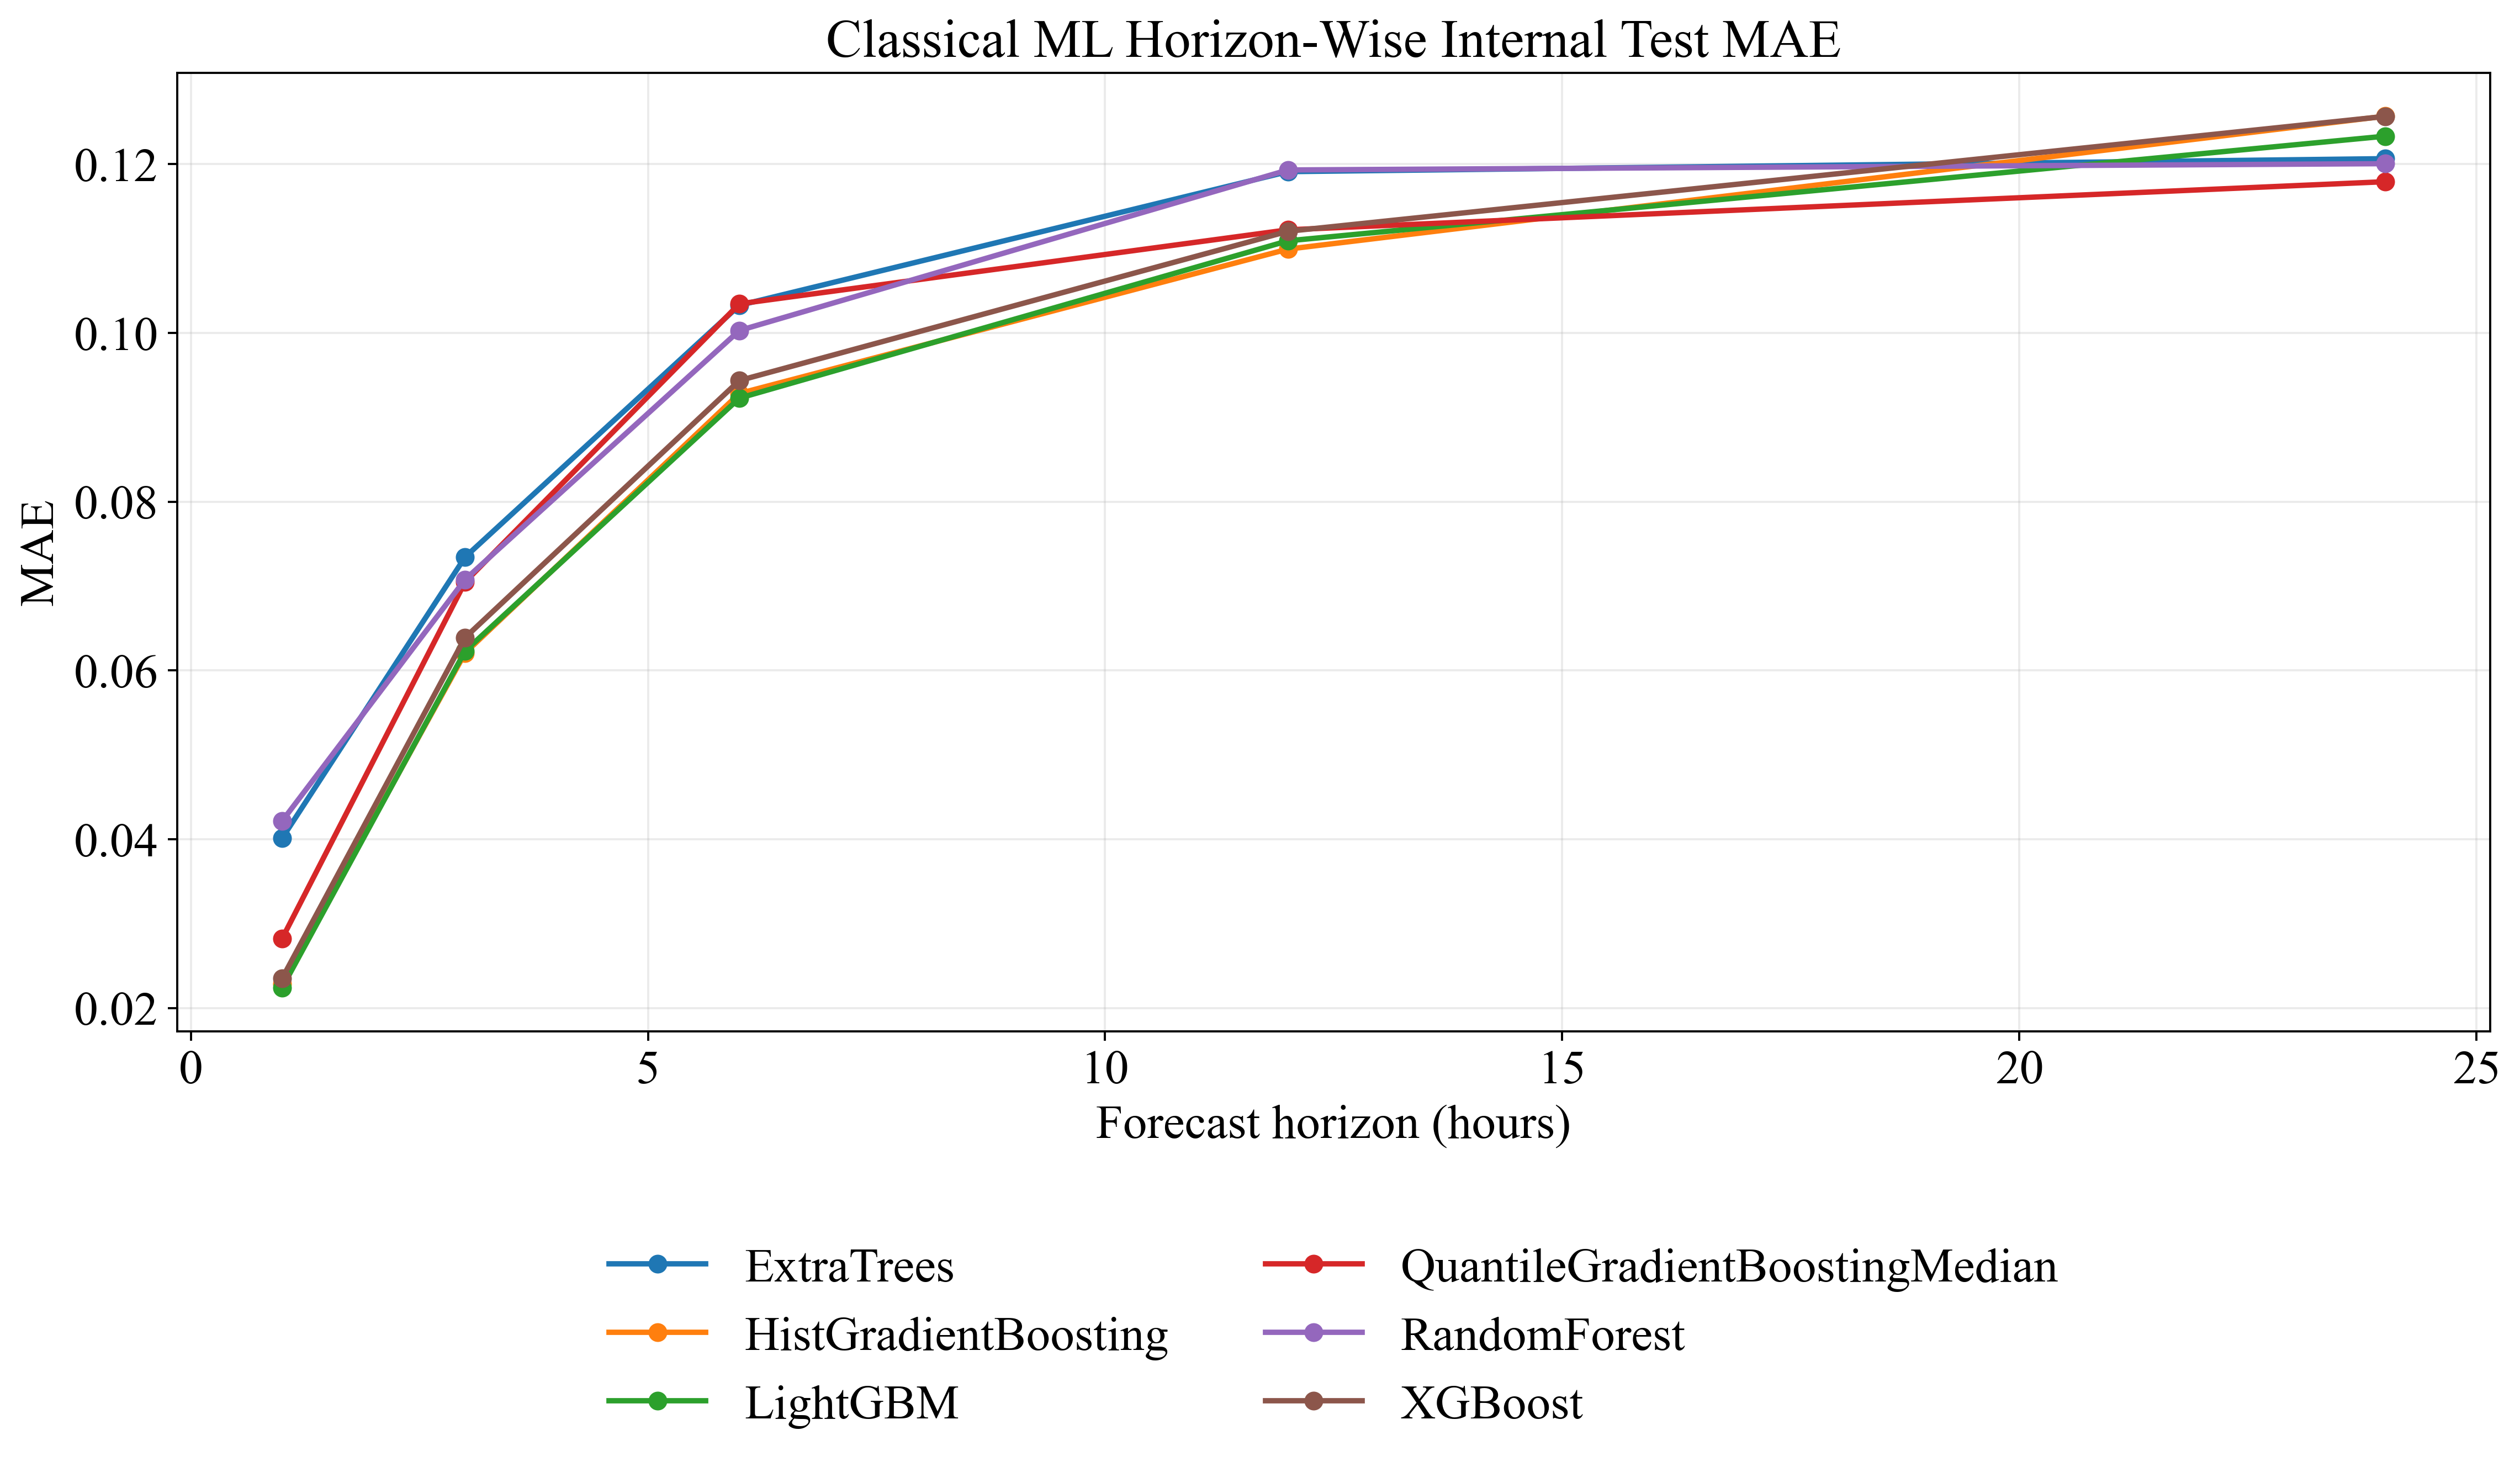

Saved figure: artifacts/figures/21_classical_ml_horizon_performance.png


In [9]:

# Save predictions, metrics, leaderboard, and comparison figures.
predictions=pd.concat(prediction_frames, ignore_index=True)
metrics=point_metric_rows(predictions)
efficiency=pd.DataFrame(model_records)
metrics=metrics.merge(efficiency[["model_name","family","train_time_sec","inference_time_sec","model_path"]], on="model_name", how="left")
predictions.to_parquet(PRED_DIR/"03_classical_ml_predictions.parquet", index=False)
metrics.to_csv(METRICS_DIR/"03_classical_ml_metrics.csv", index=False)
leaderboard=metrics[metrics.split.eq("internal_test")].groupby(["model_name","family"], as_index=False).agg(MAE=("MAE","mean"),RMSE=("RMSE","mean"),nRMSE=("nRMSE","mean"),MASE=("MASE","mean"),R2=("R2","mean"),PICP90=("PICP90","mean"),MeanIntervalWidth=("MeanIntervalWidth","mean"),train_time_sec=("train_time_sec","first"),inference_time_sec=("inference_time_sec","first")).sort_values("MAE")
leaderboard.to_csv(TABLES_DIR/"07_classical_ml_leaderboard.csv", index=False)
# Taskwise metrics are the primary fair evidence for the multi-horizon experiment.
taskwise=metrics[metrics.split.eq("internal_test")].sort_values(["horizon","target","MAE","model_name"])
taskwise.to_csv(TABLES_DIR/"07b_classical_ml_taskwise_internal_metrics.csv", index=False)
horizon_summary=taskwise.groupby(["horizon","model_name","family"], as_index=False).agg(MAE=("MAE","mean"),RMSE=("RMSE","mean"),nRMSE=("nRMSE","mean"),MASE=("MASE","mean"),R2=("R2","mean"),PICP90=("PICP90","mean"),MeanIntervalWidth=("MeanIntervalWidth","mean")).sort_values(["horizon","MAE","model_name"])
horizon_summary.to_csv(TABLES_DIR/"07c_classical_ml_horizon_summary.csv", index=False)
wide=horizon_summary.pivot_table(index=["model_name","family"], columns="horizon", values=["MAE","RMSE","R2"], aggfunc="mean")
wide.columns=[f"{metric}_H{int(h)}" for metric,h in wide.columns]
wide.reset_index().to_csv(TABLES_DIR/"07d_classical_ml_wide_horizon_metrics.csv", index=False)
for horizon in sorted(taskwise.horizon.unique()):
    taskwise[taskwise.horizon.eq(horizon)].to_csv(TABLES_DIR/f"07e_classical_ml_H{int(horizon):02d}_taskwise_metrics.csv", index=False)
external_taskwise=metrics[metrics.split.eq("external_locked")].sort_values(["horizon","target","MAE","model_name"])
external_taskwise.to_csv(TABLES_DIR/"07f_classical_ml_taskwise_external_metrics.csv", index=False)
external_summary=external_taskwise.groupby(["horizon","model_name","family"], as_index=False).agg(MAE=("MAE","mean"),RMSE=("RMSE","mean"),nRMSE=("nRMSE","mean"),MASE=("MASE","mean"),R2=("R2","mean"),PICP90=("PICP90","mean"),MeanIntervalWidth=("MeanIntervalWidth","mean")).sort_values(["horizon","MAE","model_name"])
external_summary.to_csv(TABLES_DIR/"07g_classical_ml_external_horizon_summary.csv", index=False)
display(leaderboard.head(15))
display(horizon_summary.groupby("horizon").head(5))
display(external_summary.groupby("horizon").head(5))
# Metric comparison figure.
plot_df=leaderboard.head(12).iloc[::-1]
fig,ax=plt.subplots(figsize=(14,10)); ax.barh(plot_df.model_name, plot_df.MAE, color="#5B8FA8"); ax.set_title("Classical ML Internal Test MAE Ranking"); ax.set_xlabel("Overview mean MAE across target–horizon tasks"); annotate_bars(ax,"{:.3f}"); save_figure(fig,"20_classical_ml_metric_comparison.png",0.12)
# Horizon performance for top models.
top_models=leaderboard.head(6).model_name.tolist(); hdf=metrics[(metrics.split.eq("internal_test")) & (metrics.model_name.isin(top_models))].groupby(["model_name","horizon"], as_index=False).agg(MAE=("MAE","mean"))
fig,ax=plt.subplots(figsize=(14,8))
for model,g in hdf.groupby("model_name"):
    ax.plot(g.horizon, g.MAE, marker="o", linewidth=2, label=model)
ax.set_title("Classical ML Horizon-Wise Internal Test MAE"); ax.set_xlabel("Forecast horizon (hours)"); ax.set_ylabel("MAE"); legend_below(ax,2); save_figure(fig,"21_classical_ml_horizon_performance.png",0.28)

# Target-horizon metric heatmaps for the strongest model in this notebook.
# One 2 x 3 canvas is used for the six primary metrics so the article can compare targets and horizons without averaging them away.


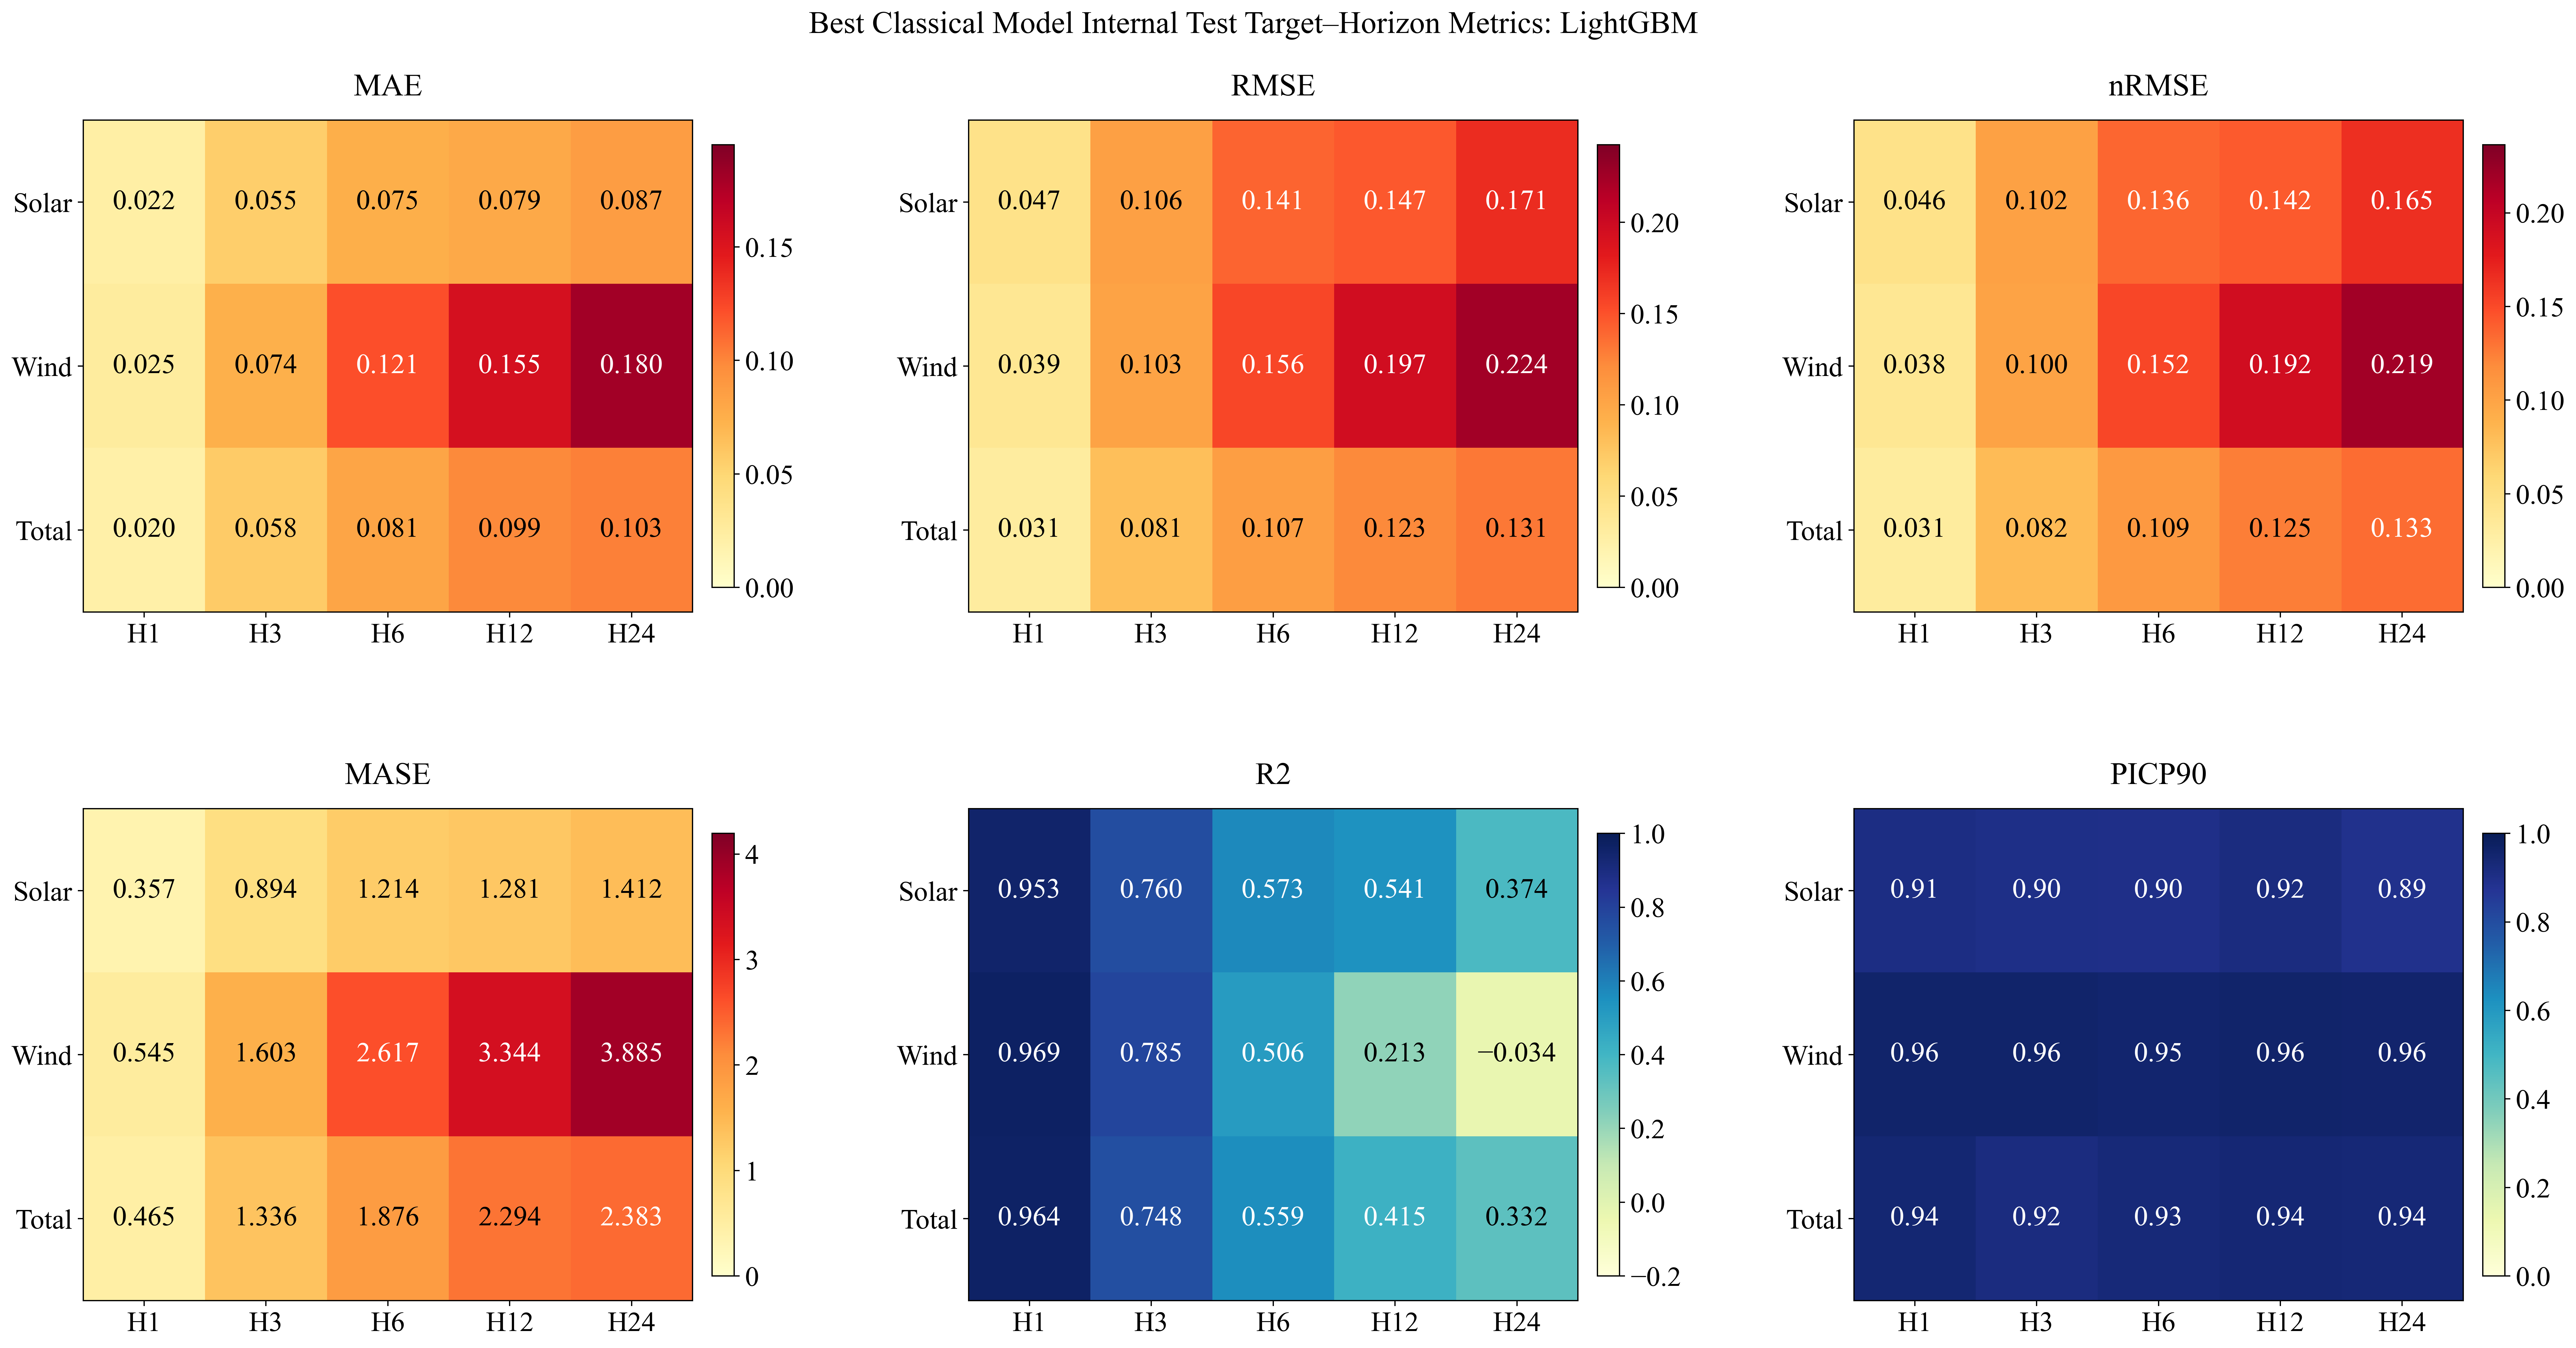

Saved figure: artifacts/figures/22_classical_best_model_target_horizon_metrics.png


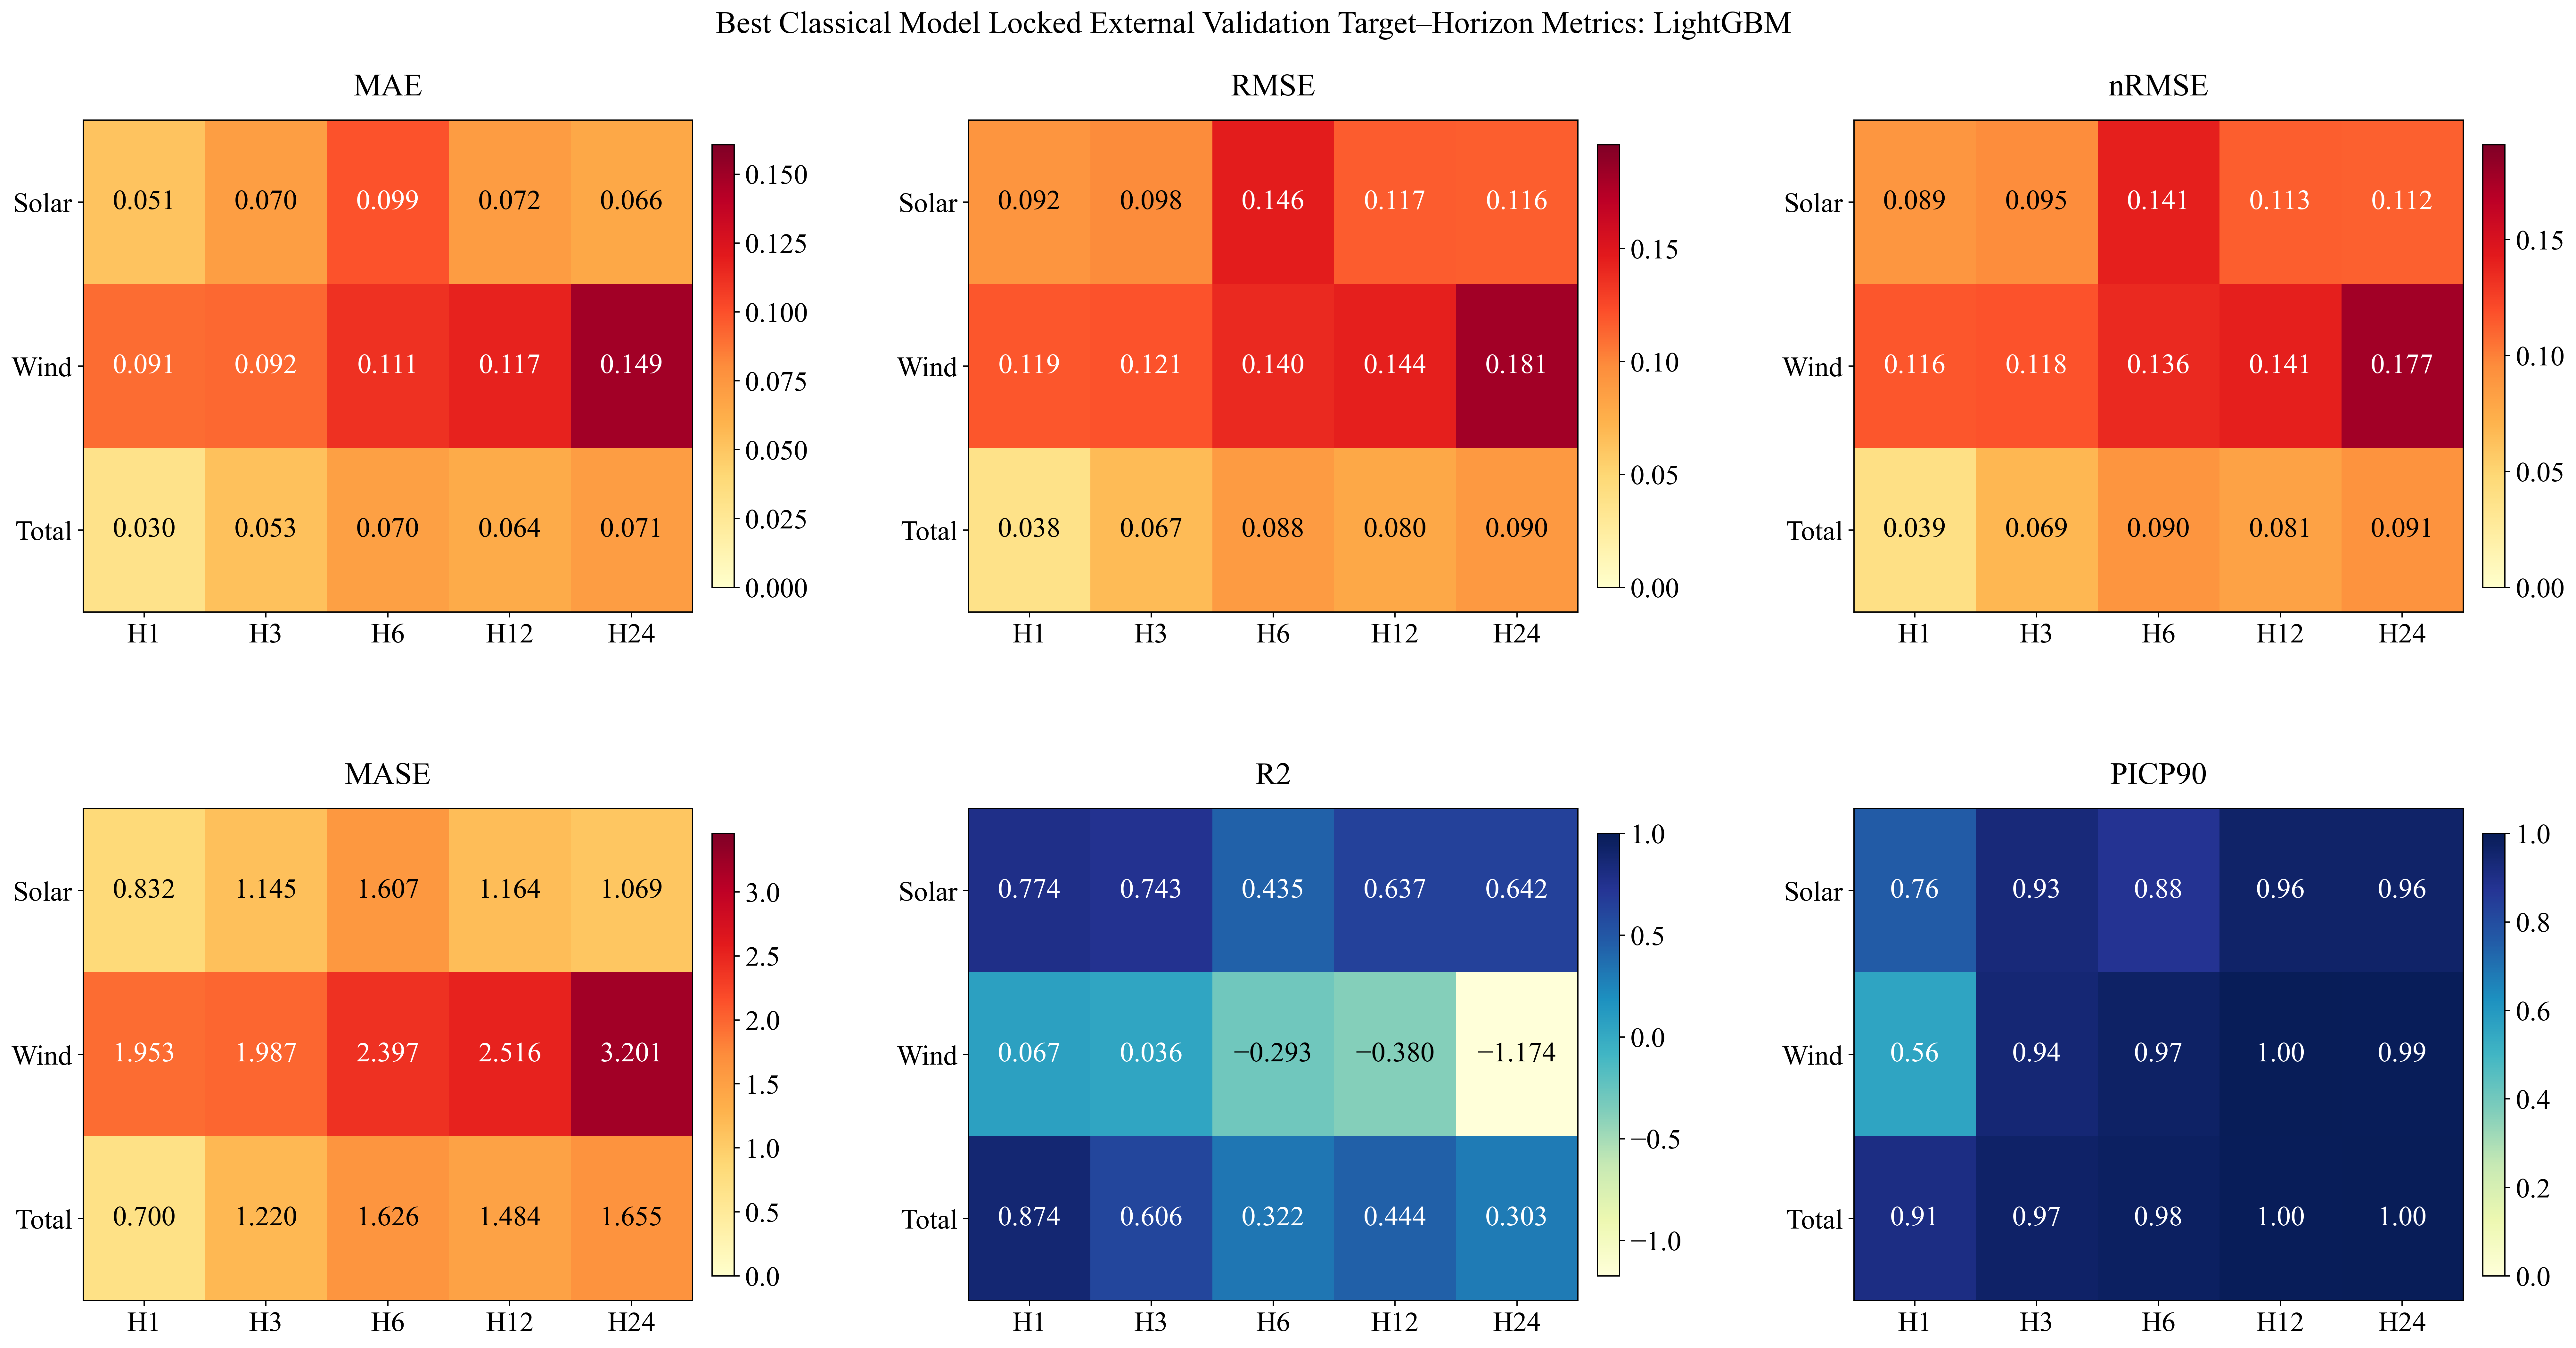

Saved figure: artifacts/figures/23_classical_best_model_external_validation_target_horizon_metrics.png
Saved classical predictions and metrics.


In [10]:
def format_metric_label(value, metric):
    text=f"{value:.2f}" if metric=="PICP90" else f"{value:,.3f}"
    return text.replace("-","−")

def target_horizon_metric_heatmaps(metrics_df, split_name, model_name, filename, title_prefix):
    targets=[t for t in ["solar","wind","total"] if t in metrics_df.target.unique()]
    horizons=sorted(metrics_df.horizon.unique())
    part=metrics_df[(metrics_df.split.eq(split_name)) & (metrics_df.model_name.eq(model_name))].copy()
    metrics_to_plot=[m for m in ["MAE","RMSE","nRMSE","MASE","R2","PICP90"] if m in part.columns and part[m].notna().any()]
    if not metrics_to_plot:
        return
    model_label=str(model_name).replace("_"," ")
    cmap_by_metric={"MAE":"YlOrRd","RMSE":"YlOrRd","nRMSE":"YlOrRd","MASE":"YlOrRd","R2":"YlGnBu","PICP90":"YlGnBu"}
    fig,axes=plt.subplots(2,3,figsize=(24,13),squeeze=False)
    axes=axes.ravel()
    for panel_idx,(ax,metric) in enumerate(zip(axes,metrics_to_plot)):
        mat=part.pivot_table(index="target", columns="horizon", values=metric, aggfunc="mean").reindex(index=targets, columns=horizons)
        data=mat.to_numpy(float)
        finite=data[np.isfinite(data)]
        if metric=="R2" and finite.size:
            vmin=min(-0.2,float(np.nanmin(finite))); vmax=max(1.0,float(np.nanmax(finite)))
        elif metric=="PICP90":
            vmin=0.0; vmax=1.0
        elif finite.size:
            vmin=0.0; vmax=float(np.nanmax(finite))*1.08 if np.nanmax(finite)>0 else 1.0
        else:
            vmin=0.0; vmax=1.0
        im=ax.imshow(data,cmap=cmap_by_metric.get(metric,"viridis"),vmin=vmin,vmax=vmax,aspect="auto")
        ax.set_xticks(range(len(horizons)))
        ax.set_xticklabels([f"H{int(h)}" for h in horizons], rotation=0)
        ax.set_yticks(range(len(targets)))
        ax.set_yticklabels([t.capitalize() for t in targets])
        ax.set_title(metric, pad=16)
        ax.grid(False)
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                val=data[i,j]
                if np.isfinite(val):
                    rgba=im.cmap(im.norm(val)); lum=0.299*rgba[0]+0.587*rgba[1]+0.114*rgba[2]
                    label=format_metric_label(val, metric)
                    ax.text(j,i,label,ha="center",va="center",fontsize=18,color="black" if lum>0.58 else "white")
        cb=fig.colorbar(im, ax=ax, fraction=0.034, pad=0.030)
        cb.ax.tick_params(labelsize=18)
    for ax in axes[len(metrics_to_plot):]:
        ax.axis("off")
    fig.suptitle(f"{title_prefix} Target–Horizon Metrics: {model_label}", y=0.965, fontsize=20)
    fig.subplots_adjust(left=0.065,right=0.965,bottom=0.08,top=0.89,wspace=0.36,hspace=0.40)
    save_figure(fig, filename, bottom=0.08, left=0.065, right=0.965, top=0.89)

best_classical_model=leaderboard.iloc[0].model_name
target_horizon_metric_heatmaps(metrics,"internal_test",best_classical_model,"22_classical_best_model_target_horizon_metrics.png","Best Classical Model Internal Test")
target_horizon_metric_heatmaps(metrics,"external_locked",best_classical_model,"23_classical_best_model_external_validation_target_horizon_metrics.png","Best Classical Model Locked External Validation")

print("Saved classical predictions and metrics.")


## Notebook Completion Checklist

- Persistence, seasonal persistence, rolling mean, linear/statistical, Bayesian/probabilistic, tree, and boosting baselines were trained or attempted with logged skips when infeasible.
- Model selection and interval calibration used only training and validation data.
- Internal test metrics, predictions, model artifacts, leaderboard tables, and PNG comparison figures were saved.
- Locked external validation was computed only after model selection and interval calibration, with no external feedback into training or selection.
